# CIR Interest-Rate Model and Treasury Curve Analysis

## Research question

**Can the CIR model reproduce observed U.S. Treasury-rate dynamics and the term structure of interest rates?**

This notebook downloads constant-maturity Treasury yields from FRED, estimates CIR and Vasicek short-rate dynamics using exact transition likelihoods, simulates paths, constructs zero-coupon curves, and compares them with the most recent observed Treasury curve. It requires only pandas, scipy, plotly, and ipywidgets.

## Model setup

- CIR: dr = kappa(theta - r)dt + sigma sqrt(r)dW. It is mean-reverting and enforces non-negative rates in the continuous-time model.
- Vasicek: dr = kappa(theta - r)dt + sigma dW. It is analytically convenient but permits negative rates.
- The 3-month Treasury yield is a practical short-rate proxy.
- Parameters are estimated from daily changes using exact transition densities, then used for risk-neutral-style zero-coupon pricing as an illustrative comparison.

Important limitation: a single-factor short-rate model cannot generally fit every point on an observed yield curve without a market-price-of-risk adjustment or a time-dependent extension such as CIR++.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import stats
from scipy.optimize import minimize
from ipywidgets import interact, FloatSlider

START_DATE = '2000-01-01'
END_DATE = pd.Timestamp.today().date().isoformat()
DT = 1 / 252
N_PATHS = 2_000
SIMULATION_YEARS = 10
RANDOM_SEED = 42
FRED_SERIES = {'3M': 'DGS3MO', '6M': 'DGS6MO', '1Y': 'DGS1', '2Y': 'DGS2', '5Y': 'DGS5', '10Y': 'DGS10', '30Y': 'DGS30'}
MATURITIES = pd.Series({'3M': .25, '6M': .5, '1Y': 1., '2Y': 2., '5Y': 5., '10Y': 10., '30Y': 30.})

Yield observations: 6,657; last curve date: 2026-08-13


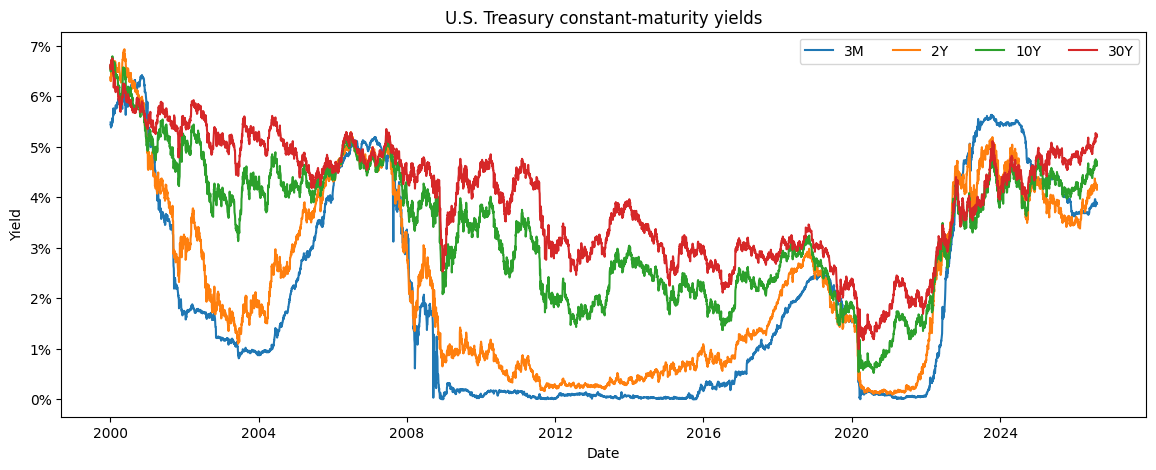

In [2]:
def fred_series(series_id, start=START_DATE, end=END_DATE):
    # FRED graph CSV is public and does not require an API key.
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cos=Close&coed={end}'
    data = pd.read_csv(url, parse_dates=['observation_date'], na_values='.')
    data = data.rename(columns={'observation_date': 'Date', series_id: series_id}).set_index('Date')
    return pd.to_numeric(data[series_id], errors='coerce').loc[start:end]


yields_pct = pd.concat({label: fred_series(series_id) for label, series_id in FRED_SERIES.items()}, axis=1).dropna(how='all')
yields = yields_pct / 100
short_rate = yields['3M'].dropna().clip(lower=1e-6)
print(f'Yield observations: {len(yields):,}; last curve date: {yields.dropna(how="all").index.max().date()}')

fig, axis = plt.subplots(figsize=(14, 5))
for column in ['3M', '2Y', '10Y', '30Y']:
    axis.plot(yields.index, yields[column], label=column)
axis.set(title='U.S. Treasury constant-maturity yields', xlabel='Date', ylabel='Yield')
axis.yaxis.set_major_formatter('{x:.0%}'); axis.legend(ncol=4); plt.show()

In [3]:
def vasicek_neg_log_likelihood(log_parameters, rates, dt=DT):
    kappa, theta, sigma = np.exp(log_parameters)
    previous, following = rates[:-1], rates[1:]
    mean = theta + (previous - theta) * np.exp(-kappa * dt)
    variance = sigma**2 * (1 - np.exp(-2 * kappa * dt)) / (2 * kappa)
    return -stats.norm.logpdf(following, loc=mean, scale=np.sqrt(variance)).sum()


def cir_neg_log_likelihood(log_parameters, rates, dt=DT):
    kappa, theta, sigma = np.exp(log_parameters)
    previous, following = np.maximum(rates[:-1], 1e-8), np.maximum(rates[1:], 1e-8)
    scale = sigma**2 * (1 - np.exp(-kappa * dt)) / (4 * kappa)
    degrees_freedom = 4 * kappa * theta / sigma**2
    non_centrality = 4 * kappa * np.exp(-kappa * dt) * previous / (sigma**2 * (1 - np.exp(-kappa * dt)))
    log_density = stats.ncx2.logpdf(following / scale, degrees_freedom, non_centrality) - np.log(scale)
    return -np.nansum(log_density)


rate_values = short_rate.values
initial_guess = np.log([0.5, max(short_rate.mean(), .01), max(short_rate.diff().std() * np.sqrt(252), .01)])
vasicek_fit = minimize(vasicek_neg_log_likelihood, initial_guess, args=(rate_values,), method='Nelder-Mead')
cir_fit = minimize(cir_neg_log_likelihood, initial_guess, args=(rate_values,), method='Nelder-Mead')
vasicek_parameters = pd.Series(np.exp(vasicek_fit.x), index=['kappa', 'theta', 'sigma'], name='Vasicek')
cir_parameters = pd.Series(np.exp(cir_fit.x), index=['kappa', 'theta', 'sigma'], name='CIR')
parameter_table = pd.concat([vasicek_parameters, cir_parameters], axis=1)
display(parameter_table.style.format('{:.4%}'))
print(f'Vasicek optimisation success: {vasicek_fit.success}; CIR optimisation success: {cir_fit.success}')

,Vasicek,CIR
kappa,10.5640%,17.5221%
theta,1.4081%,1.6372%
sigma,0.7158%,8.3339%


Vasicek optimisation success: True; CIR optimisation success: True


In [4]:
def simulate_rates(parameters, r0, model='CIR', years=SIMULATION_YEARS, paths=N_PATHS, dt=DT, seed=RANDOM_SEED):
    kappa, theta, sigma = parameters[['kappa', 'theta', 'sigma']]
    steps, rng = int(years / dt), np.random.default_rng(seed)
    rate_paths = np.empty((steps + 1, paths)); rate_paths[0] = r0
    shocks = rng.standard_normal((steps, paths))
    for step in range(steps):
        previous = rate_paths[step]
        diffusion = sigma * (np.sqrt(np.maximum(previous, 0)) if model == 'CIR' else 1) * np.sqrt(dt) * shocks[step]
        rate_paths[step + 1] = previous + kappa * (theta - previous) * dt + diffusion
        if model == 'CIR':
            rate_paths[step + 1] = np.maximum(rate_paths[step + 1], 0)
    return rate_paths


def cir_zero_coupon_yield(maturity, r0, parameters):
    kappa, theta, sigma = parameters[['kappa', 'theta', 'sigma']]
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    denominator = (gamma + kappa) * (np.exp(gamma * maturity) - 1) + 2 * gamma
    b_factor = 2 * (np.exp(gamma * maturity) - 1) / denominator
    a_factor = (2 * gamma * np.exp((kappa + gamma) * maturity / 2) / denominator) ** (2 * kappa * theta / sigma**2)
    price = a_factor * np.exp(-b_factor * r0)
    return -np.log(price) / maturity


def vasicek_zero_coupon_yield(maturity, r0, parameters):
    kappa, theta, sigma = parameters[['kappa', 'theta', 'sigma']]
    b_factor = (1 - np.exp(-kappa * maturity)) / kappa
    log_a = (theta - sigma**2 / (2 * kappa**2)) * (b_factor - maturity) - sigma**2 * b_factor**2 / (4 * kappa)
    return -(log_a - b_factor * r0) / maturity


latest_curve = yields.dropna(how='all').iloc[-1].reindex(MATURITIES.index)
current_short_rate = short_rate.loc[:latest_curve.name].iloc[-1]
curve_comparison = pd.DataFrame({'Observed Treasury': latest_curve,
    'CIR': [cir_zero_coupon_yield(maturity, current_short_rate, cir_parameters) for maturity in MATURITIES],
    'Vasicek': [vasicek_zero_coupon_yield(maturity, current_short_rate, vasicek_parameters) for maturity in MATURITIES]}, index=MATURITIES.index)
curve_comparison.index.name = 'Maturity'
curve_errors = ((curve_comparison.sub(curve_comparison['Observed Treasury'], axis=0)) ** 2).mean().pow(.5).rename('Curve RMSE')
display(curve_comparison.style.format('{:.2%}')); display(curve_errors.to_frame().style.format('{:.2%}'))

cir_paths = simulate_rates(cir_parameters, current_short_rate, 'CIR')
vasicek_paths = simulate_rates(vasicek_parameters, current_short_rate, 'Vasicek')

,Observed Treasury,CIR,Vasicek
Maturity,,,
3M,3.87%,3.82%,3.84%
6M,3.94%,3.77%,3.81%
1Y,3.97%,3.68%,3.74%
2Y,4.15%,3.51%,3.62%
5Y,4.32%,3.07%,3.31%
10Y,4.63%,2.58%,2.89%
30Y,5.21%,1.91%,2.03%


,Curve RMSE
Observed Treasury,0.00%
CIR,1.57%
Vasicek,1.44%


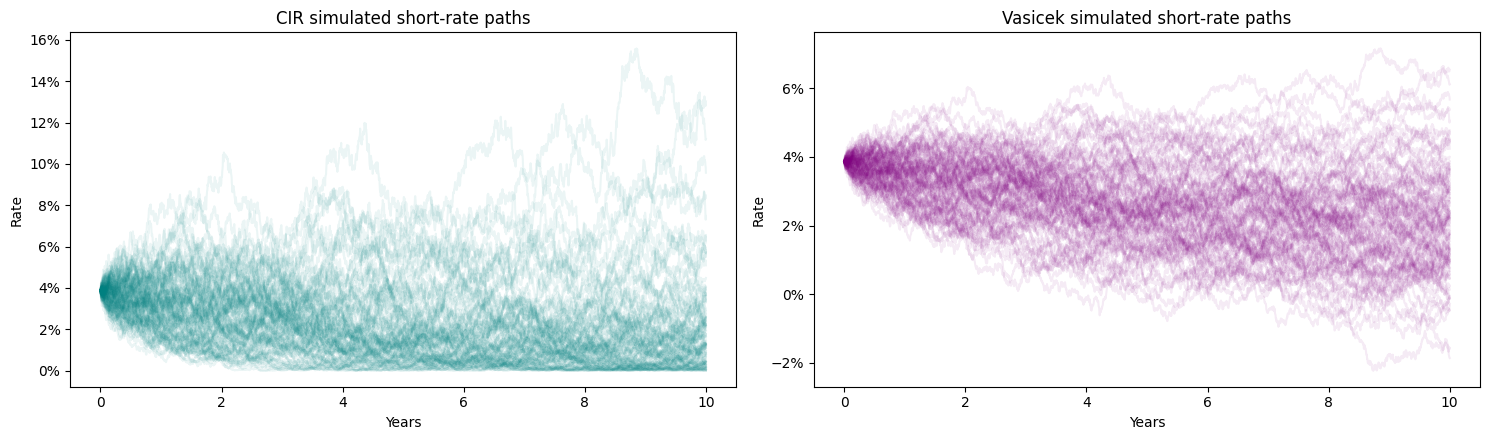

interactive(children=(FloatSlider(value=0.0387, description='Short rate', max=0.15, min=0.0001, readout_format…

In [5]:
years = np.arange(cir_paths.shape[0]) * DT
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for path in cir_paths[:, :100].T: axes[0].plot(years, path, alpha=.08, color='teal')
for path in vasicek_paths[:, :100].T: axes[1].plot(years, path, alpha=.08, color='purple')
for axis, title in zip(axes, ['CIR simulated short-rate paths', 'Vasicek simulated short-rate paths']):
    axis.set(title=title, xlabel='Years', ylabel='Rate'); axis.yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout(); plt.show()

@interact(short_rate=FloatSlider(value=float(current_short_rate), min=0.0001, max=.15, step=.0025, readout_format='.2%', description='Short rate'))
def curve_explorer(short_rate):
    curve = pd.DataFrame({'Observed Treasury': latest_curve,
        'CIR': [cir_zero_coupon_yield(maturity, short_rate, cir_parameters) for maturity in MATURITIES],
        'Vasicek': [vasicek_zero_coupon_yield(maturity, short_rate, vasicek_parameters) for maturity in MATURITIES]}, index=MATURITIES.values)
    figure = go.Figure()
    for column in curve.columns:
        figure.add_trace(go.Scatter(x=curve.index, y=curve[column], mode='lines+markers', name=column))
    figure.update_layout(title='Interactive zero-coupon yield curve comparison', xaxis_title='Maturity (years)', yaxis_title='Continuously compounded yield')
    figure.update_yaxes(tickformat='.0%'); figure.show()

## Answering the research question

Use the curve RMSE table and the path plots jointly. CIR is preferable when its non-negativity constraint materially improves the plausibility of simulated paths and its curve RMSE is competitive with Vasicek. Large errors at long maturities are evidence that one-factor short-rate dynamics alone cannot reproduce the observed term structure; a shifted or multi-factor extension is then the appropriate next model rather than over-interpreting fitted parameters.